In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels
import scikit_posthocs as sp
import sys
import scipy
import matplotlib.colors as colors

In [11]:
glom_volume = pd.read_csv("../csvs/fly_glomeruli_volume.csv")
glom_volume_single_uPN = pd.read_csv("../csvs/fly_glomeruli_volume_feedforward_single_uPN.csv")

In [12]:
#label each glomerulus appropriately 
glom_volume['glom_pn_type'] = ['single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs', 'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs',
                            'multiple uPNs', 'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs',
                            'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs',
                            'multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs','multiple uPNs', 'multiple uPNs', 'single uPN','single uPN','single uPN']

glom_volume_single_uPN['glom_pn_type'] = ['single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','single uPN','single uPN','single uPN','single uPN','single uPN',
                            'single uPN','multiple uPNs', 'single uPN']   

In [13]:
#This CSV is created by retrieve_neuron_data.ipynb
ff_synapse_count_data = pd.read_csv('../csvs/feedforward_synapse_count_data.csv')

In [14]:
#converts wide table to long table format for plotting
ff_synapse_count_data_long = pd.melt(ff_synapse_count_data)
ff_synapse_count_data_long = ff_synapse_count_data_long[ff_synapse_count_data_long['value'].notna()]

In [15]:
#populates columns based on glomerulus type for plotting
hue_list_synapse_count = [] 
for row in ff_synapse_count_data_long.iterrows():
    glom = row[1]['variable']
    hue_list_synapse_count.append(glom_volume.loc[glom_volume['glomerulus'] == glom]['glom_pn_type'].values[0]) 

ff_synapse_count_data_long['glomerulus type'] = hue_list_synapse_count
ff_synapse_count_data_long['color'] = ff_synapse_count_data_long['glomerulus type']

ff_synapse_count_data_long = ff_synapse_count_data_long[(ff_synapse_count_data_long['variable']!= 'Glomerulus 2')
                                                                                  & (ff_synapse_count_data_long['variable']!= 'Glomerulus 3')]

glom1_index = ff_synapse_count_data_long.loc[ff_synapse_count_data_long['variable'] == 'Glomerulus 1'].index
glomV_index = ff_synapse_count_data_long.loc[ff_synapse_count_data_long['variable'] == 'V'].index

for cell_index in glom1_index: 
    ff_synapse_count_data_long.at[cell_index,'color'] = 'Glomerulus 1'
for cell_index in glomV_index: 
    ff_synapse_count_data_long.at[cell_index,'color'] = 'V'    

In [16]:
#post hoc tests
uncorrected_feedforward_synapse_count_post_hoc_all = sp.posthoc_mannwhitney(ff_synapse_count_data_long,val_col='value',group_col='variable')

synapse_count_correction_results_all = statsmodels.stats.multitest.multipletests(uncorrected_feedforward_synapse_count_post_hoc_all['Glomerulus 1'], alpha=0.05, method='bonferroni')
corrected_feedforward_synapse_count_post_hoc_all = pd.DataFrame({'Glomerulus': list(uncorrected_feedforward_synapse_count_post_hoc_all['Glomerulus 1'].index),
                                               'significant': synapse_count_correction_results_all[0],
                                               'uncorrected_p_value': uncorrected_feedforward_synapse_count_post_hoc_all['Glomerulus 1'],
                                               'corrected p_value':synapse_count_correction_results_all[1]})
corrected_feedforward_synapse_count_post_hoc_all

,Glomerulus,significant,uncorrected_p_value,corrected p_value
D,D,True,9.205326e-05,0.004787
DA1,DA1,True,4.907113e-07,0.000026
DA2,DA2,True,3.551051e-05,0.001847
DA3,DA3,True,6.122240e-05,0.003184
DA4l,DA4l,True,2.176630e-05,0.001132
DA4m,DA4m,True,1.426773e-05,0.000742
DC1,DC1,True,1.195590e-05,0.000622
DC2,DC2,True,4.570593e-05,0.002377
DC3,DC3,True,8.146464e-05,0.004236
DC4,DC4,False,8.128322e-03,0.422673


In [17]:
feedforward_count_data_long_only_glom_1_medians = ff_synapse_count_data_long.groupby(by=["variable"])["value"].median()
feedforward_count_data_long_only_glom_1_medians = abs(feedforward_count_data_long_only_glom_1_medians - feedforward_count_data_long_only_glom_1_medians['Glomerulus 1'])
feedforward_count_data_medians = pd.DataFrame(feedforward_count_data_long_only_glom_1_medians)
feedforward_count_data_medians['Glomerulus'] = feedforward_count_data_medians.index
feedforward_count_data_medians['p_value']= corrected_feedforward_synapse_count_post_hoc_all['corrected p_value']
feedforward_count_data_medians

,value,Glomerulus,p_value
variable,,,
D,76.0,D,0.004787
DA1,111.5,DA1,0.000026
DA2,133.0,DA2,0.001847
DA3,139.0,DA3,0.003184
DA4l,134.0,DA4l,0.001132
DA4m,125.0,DA4m,0.000742
DC1,96.5,DC1,0.000622
DC2,79.0,DC2,0.002377
DC3,96.0,DC3,0.004236


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

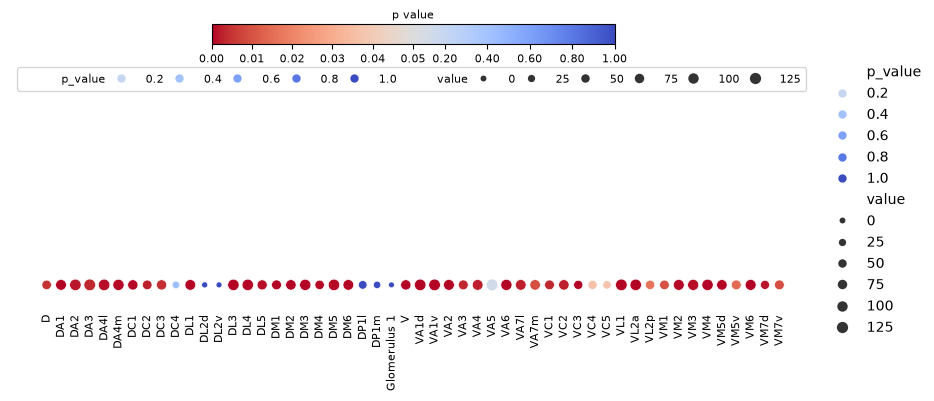

In [18]:
divnorm = colors.TwoSlopeNorm(vmin=0, vcenter=.05, vmax=1)
sm = plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True).reversed(),norm=divnorm)

ax = sns.relplot(data = feedforward_count_data_medians, y = [0.75] * 52, x='Glomerulus',size='value',
            #sizes=relplot_sizing(in_volume_cable_length_medians['value'],10,25),
            #size_order = list(range(len(in_volume_cable_length_medians['sizing']))),
            palette=sns.color_palette("coolwarm", as_cmap=True).reversed() ,hue='p_value',hue_norm=divnorm,height=4, aspect=18/8)
plt.ylim(0.75,1.25)
plt.xticks(rotation=90)
plt.xticks(fontsize=8, fontname="Liberation Sans")
plt.tick_params(left=False,bottom=False)
ax.set_yticklabels([])
ax.set_xlabels("")
legend = plt.legend(loc="upper left", ncol=13, columnspacing=0.10,frameon=None)
for text in legend.texts: 
    text.set_fontsize(8)

cbar = ax.figure.colorbar(sm,ax=plt.gca(),ticks = [0, 0.01,0.02,0.03,0.04,0.05, 0.2, 0.4, 0.6, 0.8, 1],
                          fraction=.2,shrink=0.5,orientation='horizontal',
                          location='top')#,norm=colors.TwoSlopeNorm(vmin=min(in_volume_cable_length_medians['p_value']), vcenter=.05, vmax=max(in_volume_cable_length_medians['p_value'])))#,values=divnorm(in_volume_cable_length_medians['p_value']))
cbar.ax.tick_params(labelsize=8) 
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.set_label('p value', size=8)
#cbar.ax.set_yscale('linear')

sns.despine(fig=None, ax=None, top=True, right=True, left=True, bottom=True, offset=None, trim=False)

plt.savefig('../svgs/feedforward_count_only_glom_1_relplot.svg', format="svg")
plt.show()